# What mismodeling does to a PCAT catalog

Four flares with a fast rise and exponential decay (FRED) are injected into a simulated one-day light curve with 2 minute cadence. Light curve A has a constant quiescent level. Light curve B adds a 2% rotational modulation. Each light curve is fit twice with identical priors and sampler settings, once with the model that generated it and once with a misspecified forward model.

| Fit | Data | Fitted forward model |
| --- | --- | --- |
| Profile, correct | A | FRED flares, constant level |
| Profile, misspecified | A | Gaussian flares, constant level |
| Baseline, correct | B | FRED flares, modulated level |
| Baseline, misspecified | B | FRED flares, constant level |

Each fit runs four chains of 40,000 sweeps from random prior draws, which takes about four minutes on four cores.

In [1]:
from pathlib import Path
import importlib.util
from IPython.display import Image, display

candidates = (
    root / 'examples/mismodeling_flare_catalog/mismodeling_flare_catalog.py'
    for root in (Path.cwd(), *Path.cwd().parents)
)
script = next(path for path in candidates if path.is_file())
print(f'Reading from {script}...')
specification = importlib.util.spec_from_file_location('mismodeling_example', script)
module = importlib.util.module_from_spec(specification)
specification.loader.exec_module(module)

summary = module.run_example()
for run_name, *_, label in module.FITS:
    result = summary[run_name]
    print(f"{label}: mean number of flares {result['mean_number']:.1f}, "
          f"P(N = 4) = {result['probability_injected_number']:.2f}, chi-squared per bin {result['chi2_per_bin']:.2f}")

Reading from /Users/tdaylan/Documents/work/git/pcat/examples/mismodeling_flare_catalog/mismodeling_flare_catalog.py...


FRED flares (correct): mean number of flares 4.0, P(N = 4) = 0.99, chi-squared per bin 0.97
Gaussian flares (misspecified): mean number of flares 15.1, P(N = 4) = 0.00, chi-squared per bin 0.99
Modulated baseline (correct): mean number of flares 4.0, P(N = 4) = 1.00, chi-squared per bin 1.13
Constant baseline (misspecified): mean number of flares 6.7, P(N = 4) = 0.00, chi-squared per bin 1.48


## Profile mismatch

Symmetric Gaussian components tile each asymmetric decay. The misspecified fit matches the data as well as the correct fit, with a residual consistent with noise, yet it reports about 15 flares instead of 4. A good fit alone does not validate the catalog.

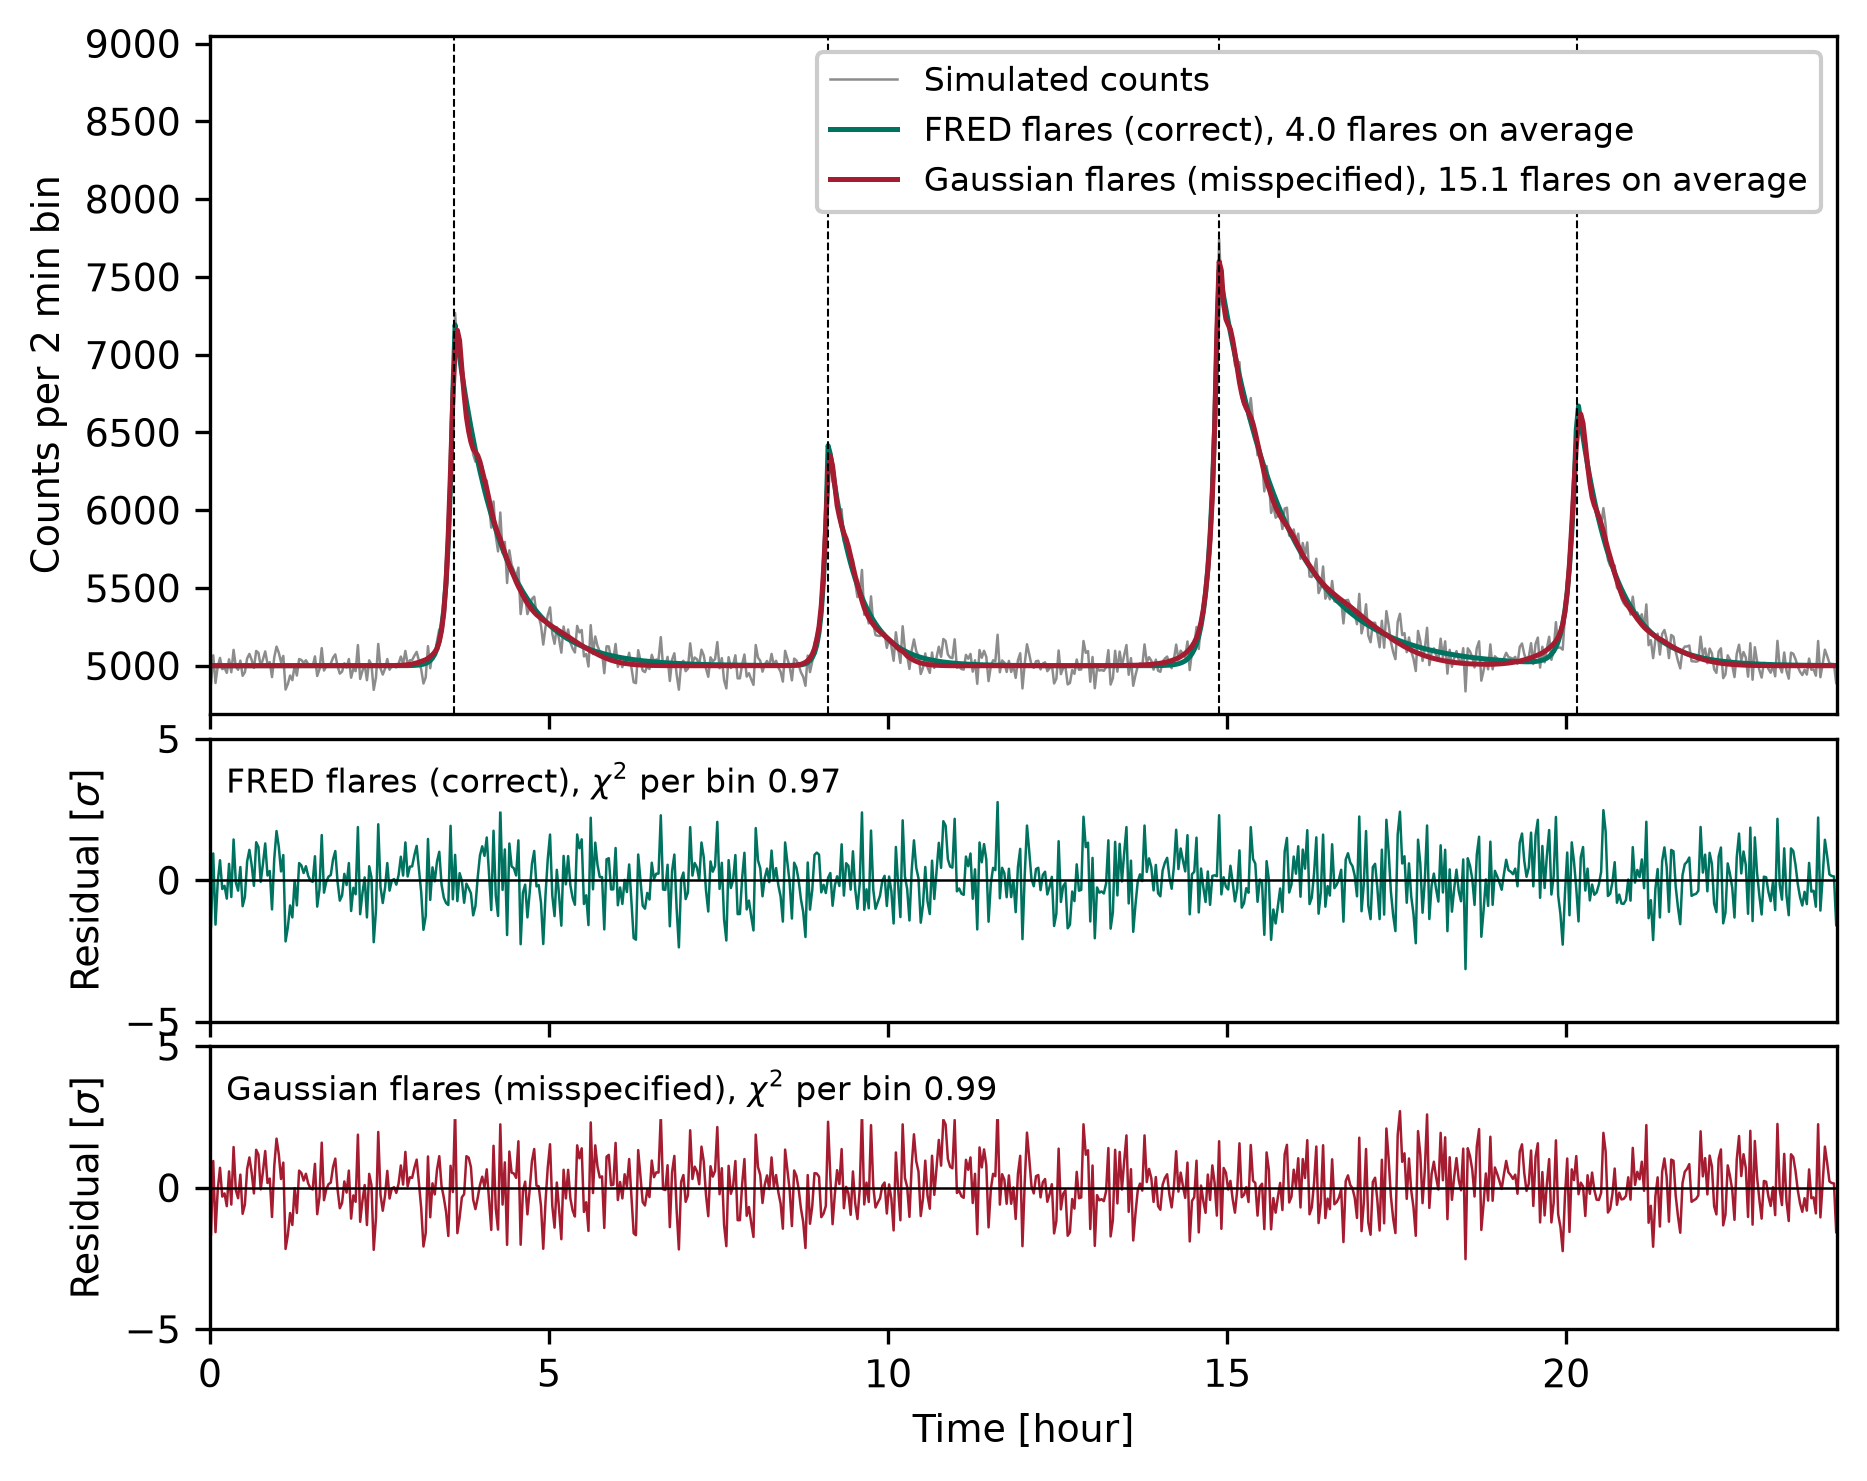

In [2]:
display(Image(filename=str(summary['figure_paths'][0])))

## Baseline mismatch

Fit with a constant quiescent level, the 2% rotational modulation of light curve B is absorbed by spurious faint flares near the modulation maxima, and the residual keeps a coherent trend where the modulation dips below the assumed level.

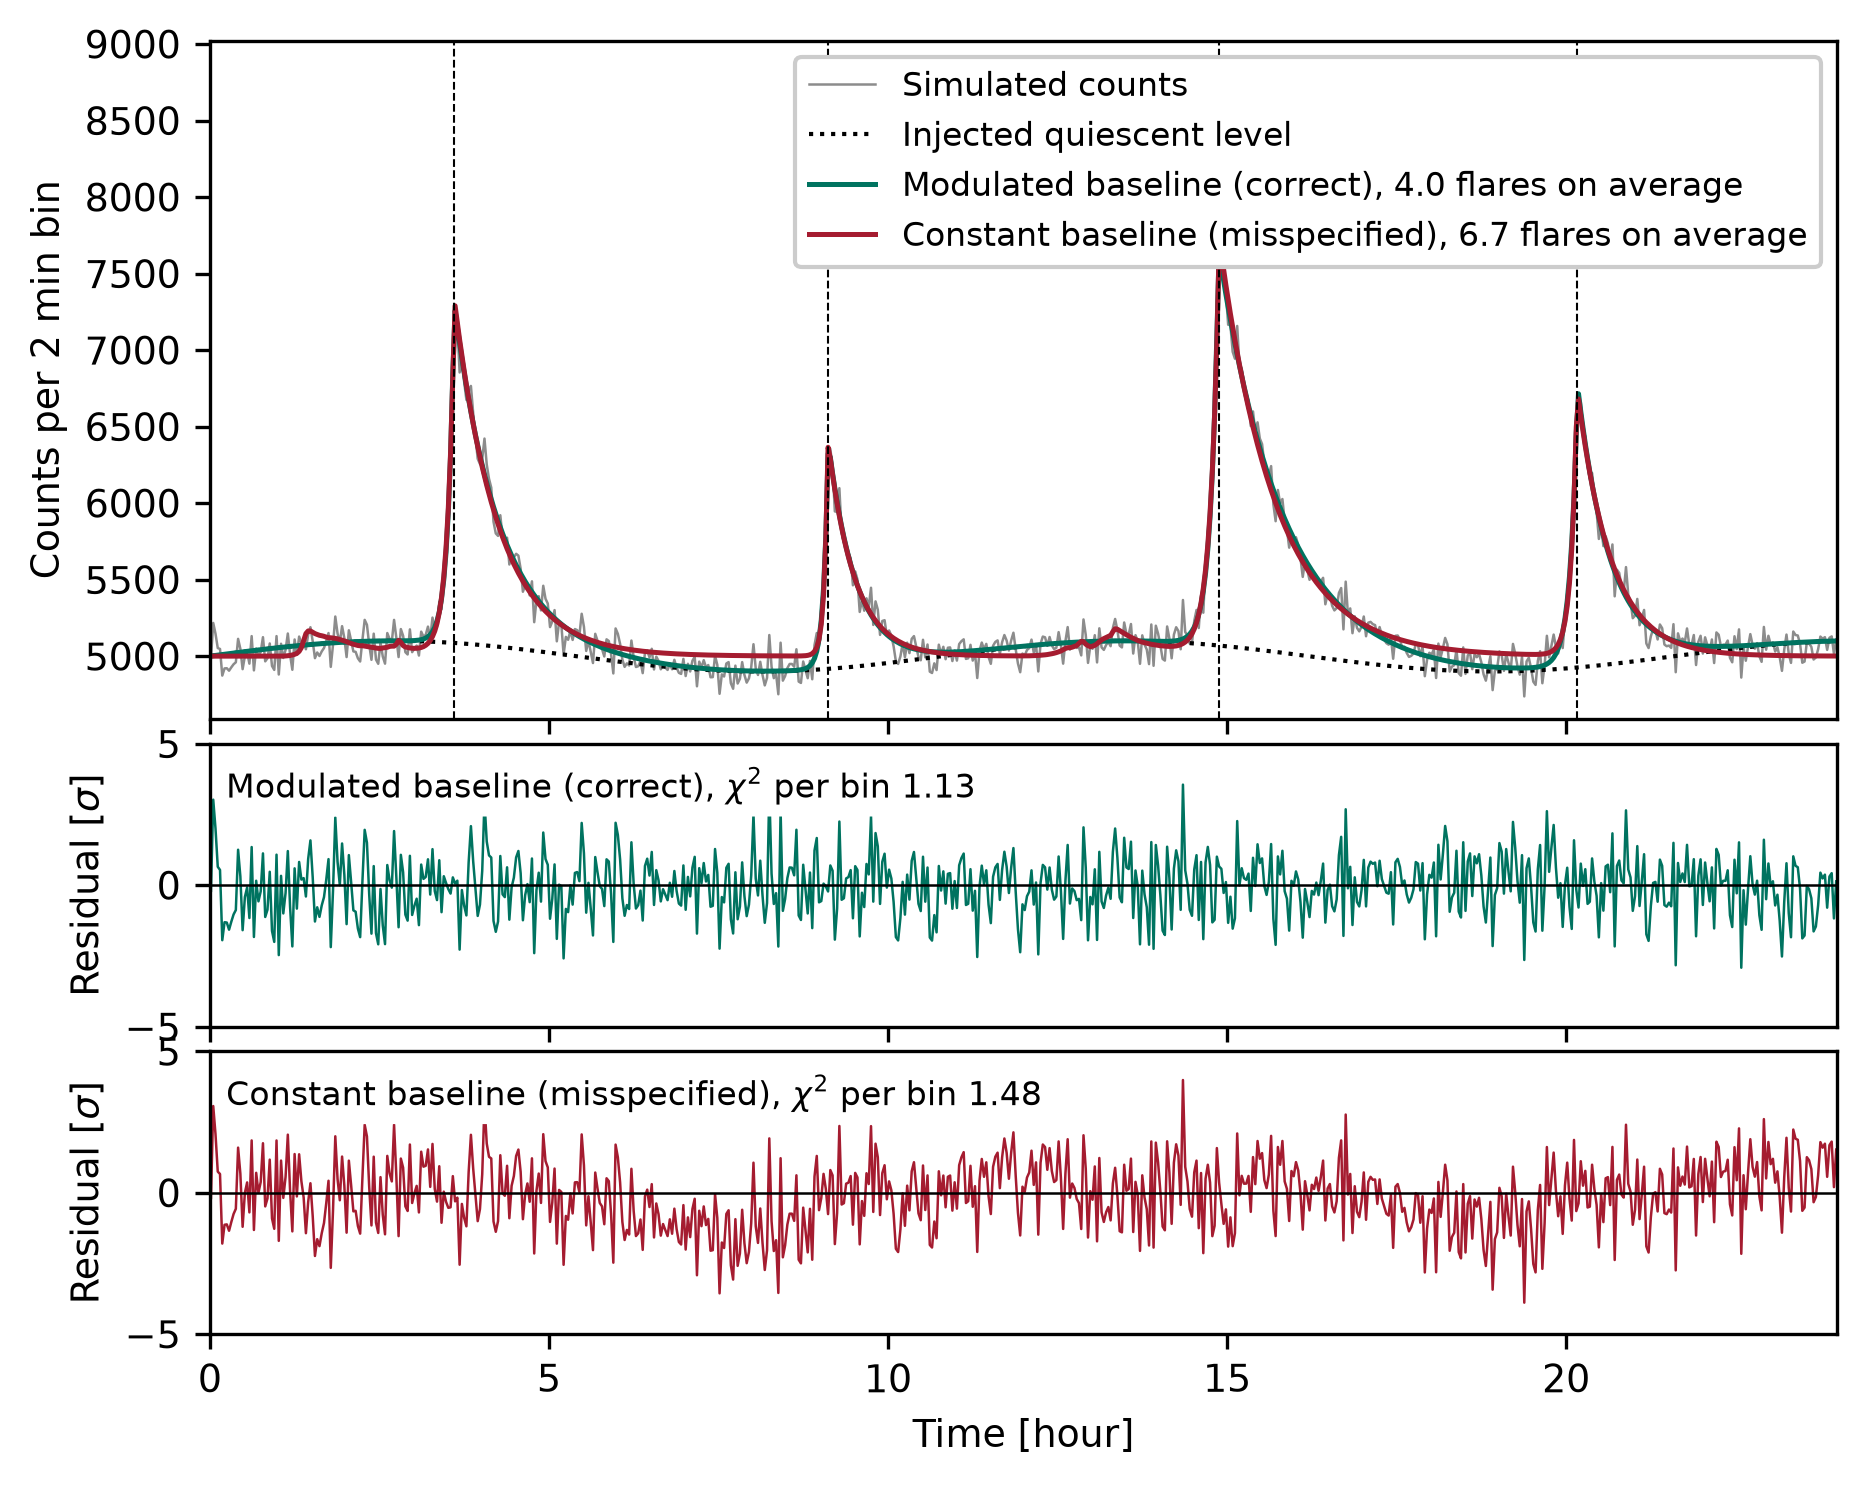

In [3]:
display(Image(filename=str(summary['figure_paths'][1])))

## Catalogs and their sizes

The correct fits place all posterior samples at the injected flares and give a posterior on the number of flares concentrated at 4. Both misspecified posteriors are narrow and exclude the injected number, so their uncertainties understate the error.

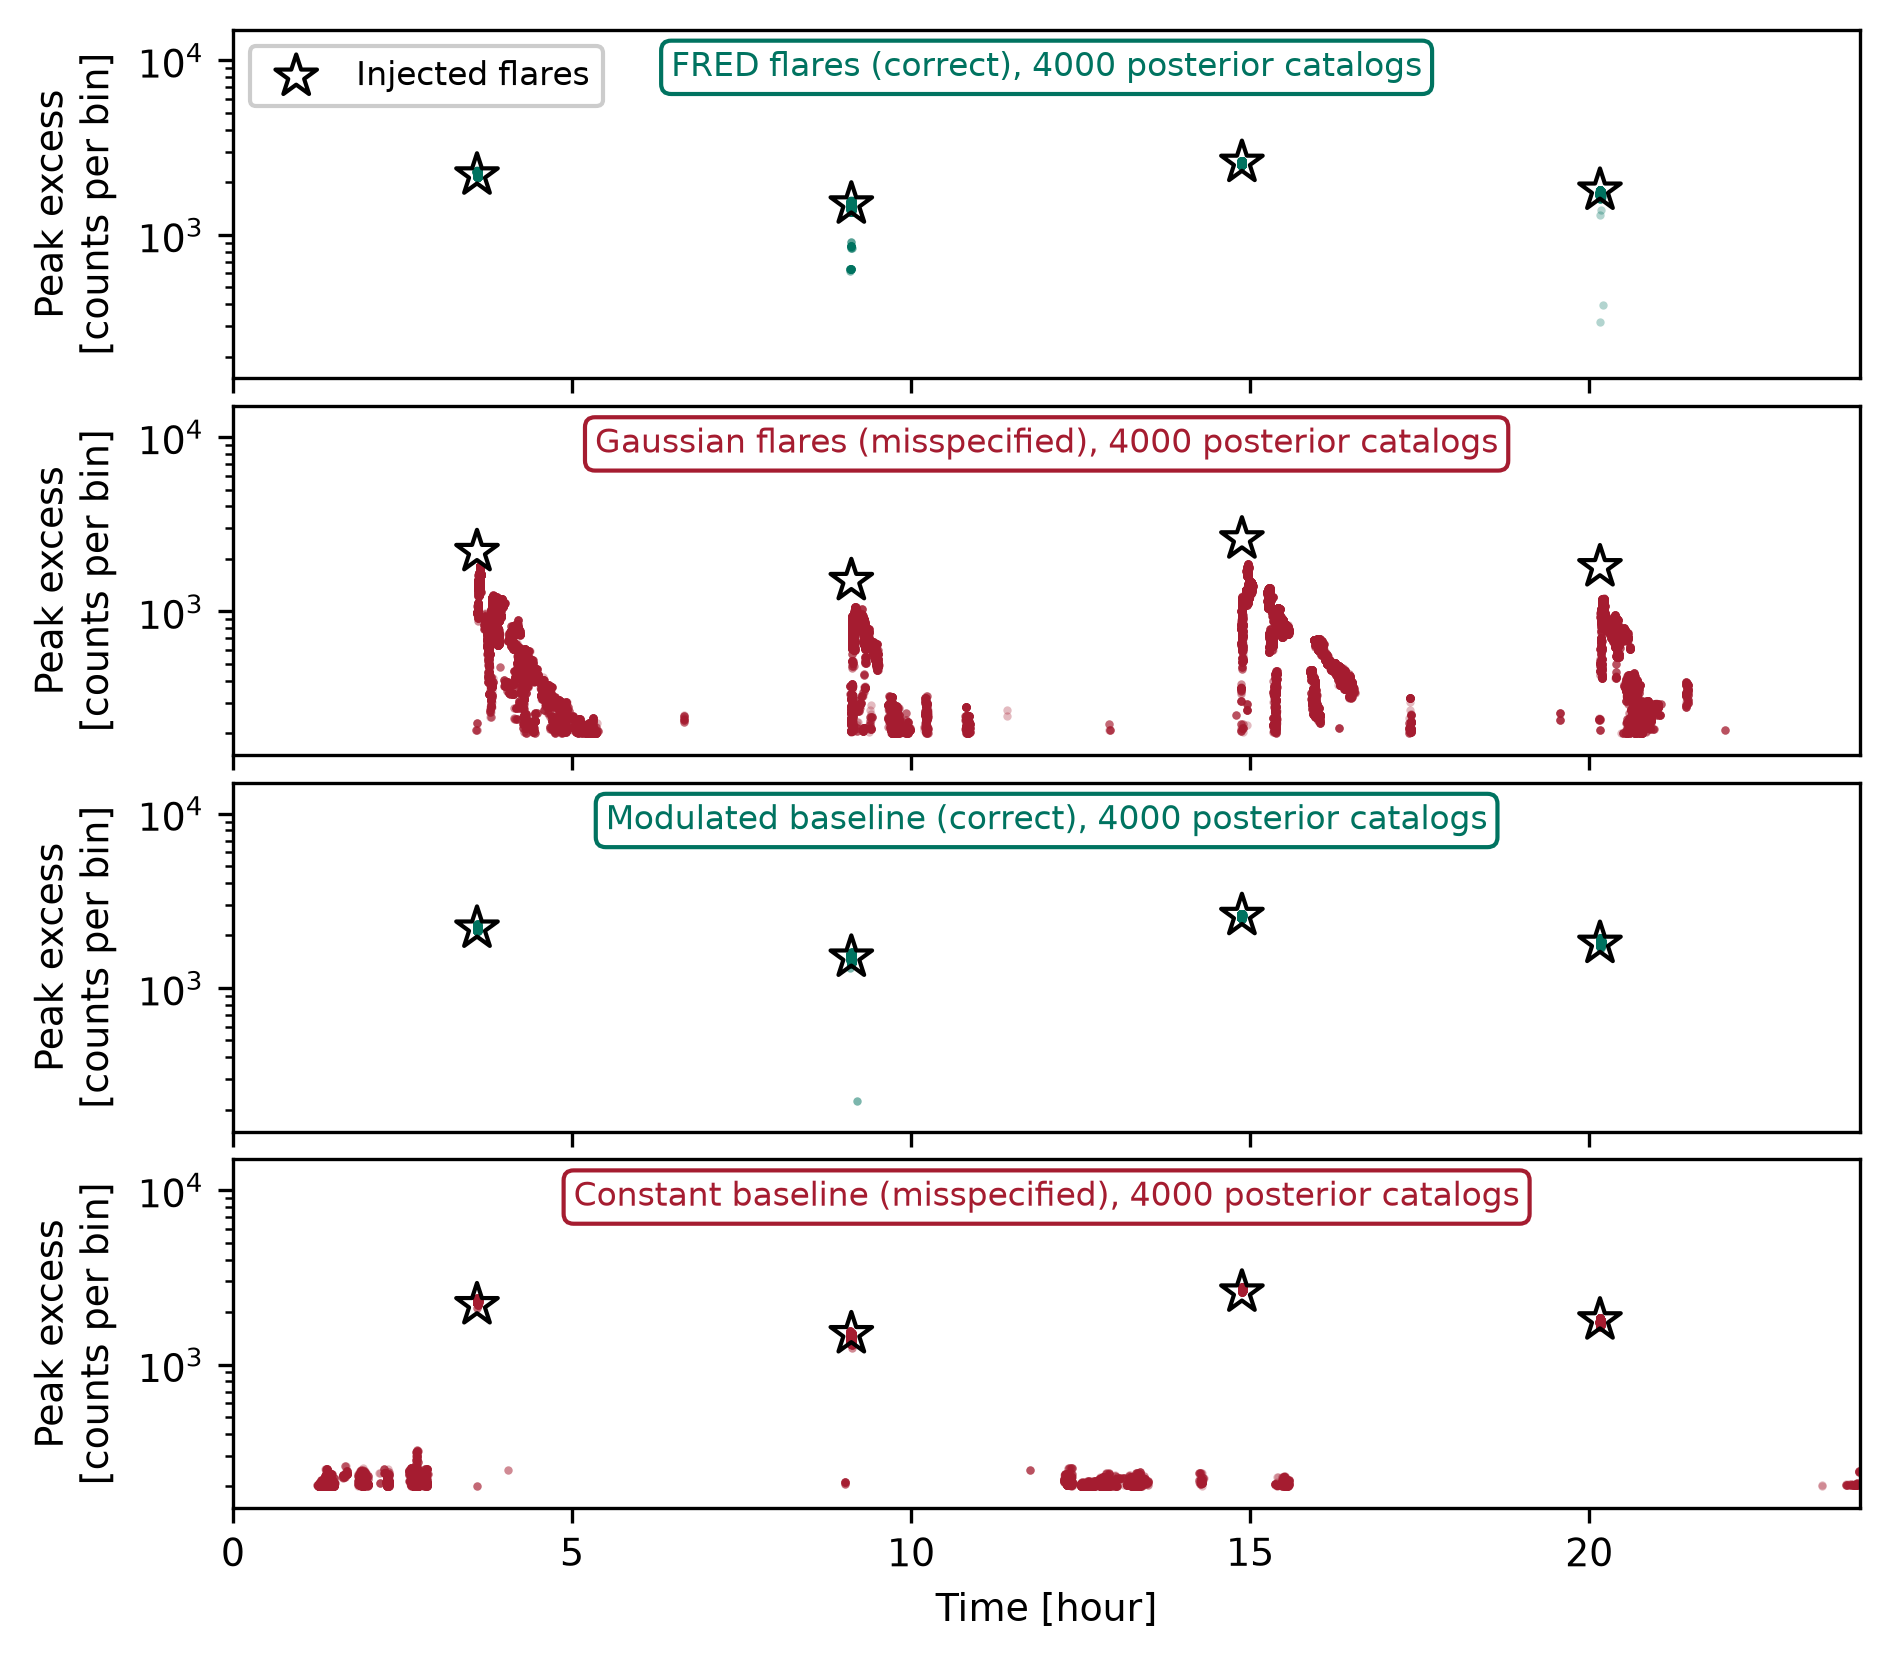

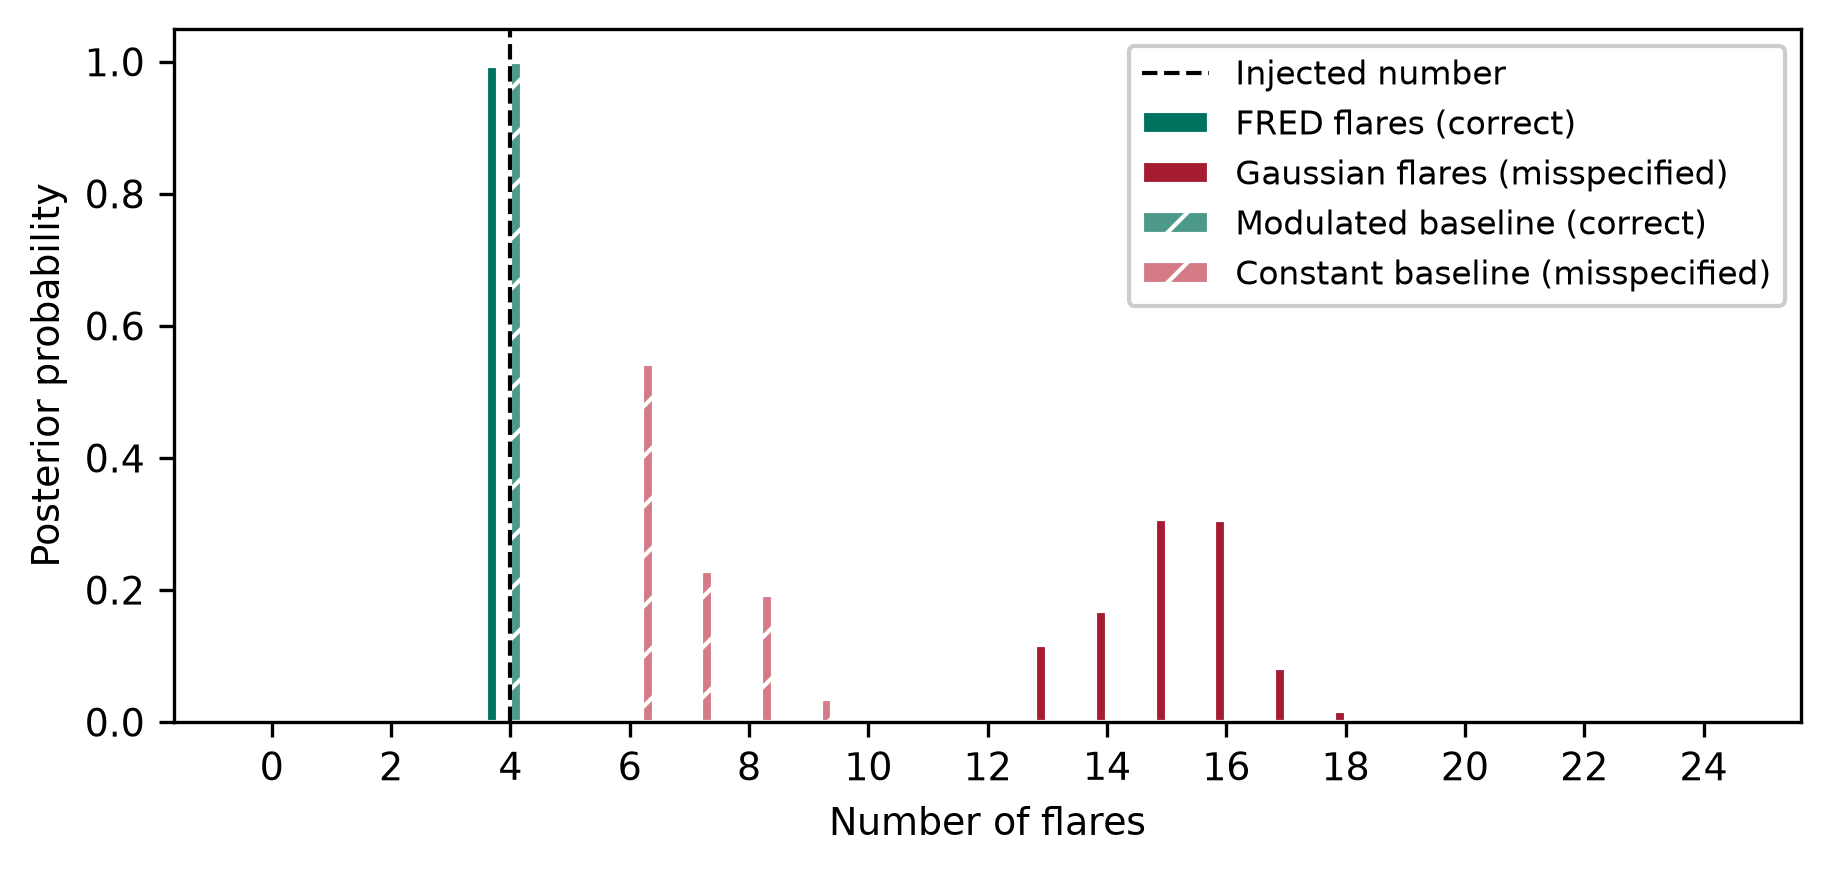

In [4]:
for path in summary['figure_paths'][2:]:
    display(Image(filename=str(path)))